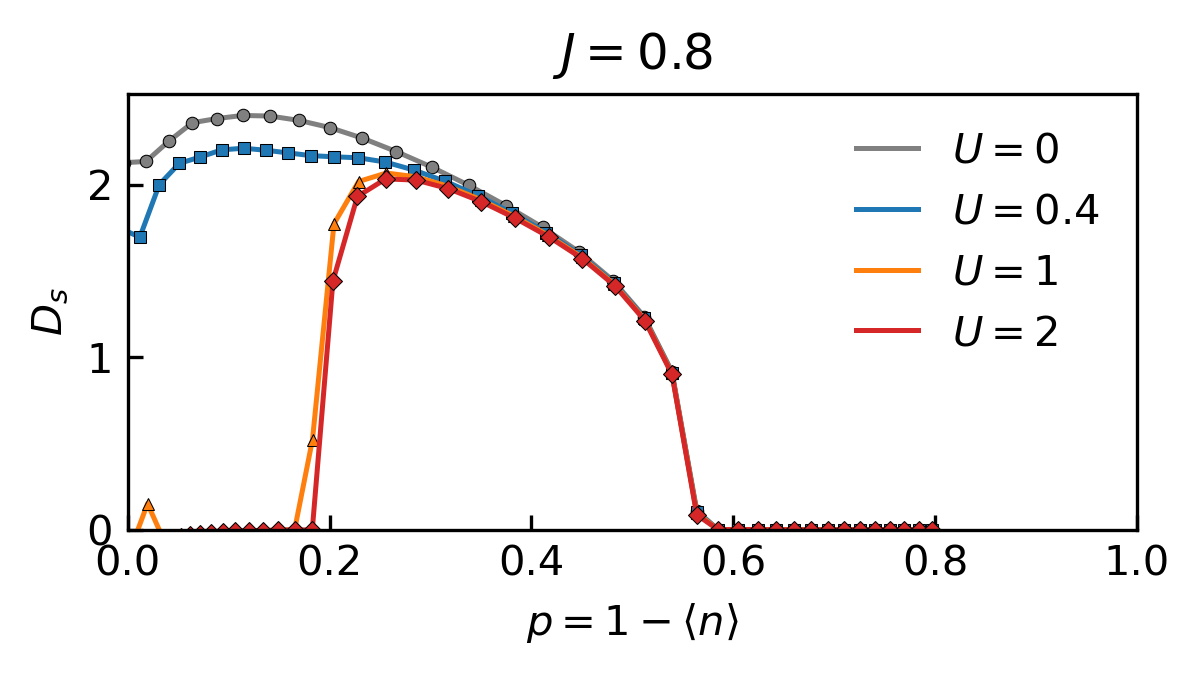

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np


def load_curve(data_dir, nk_delta, nk_stiffness, U, J, beta):
    """Load saved doping and stiffness arrays from the stiffness calculation."""
    tag = f"nkdelta{nk_delta}_nkstiff{nk_stiffness}_U={U}_J={J}_beta={beta}"
    stiffness_path = os.path.join(data_dir, f"stiffness_{tag}.npy")
    doping_path = os.path.join(data_dir, f"doping_{tag}.npy")

    stiffness = np.load(stiffness_path)
    doping = np.load(doping_path)

    order = np.argsort(doping)
    return doping[order], stiffness[order]


# -------------------------- user parameters --------------------------
data_dir = "."

# These parameters must match the data-generation script.
nk_delta = 32
nk_stiffness = 256
beta = 100
J = 0.8
U_values = [0, 0.4, 1.0, 2.0]

# Optional plotting window. Set to None to keep all data.
xlim = (0.0, 1.0)
ylim = None


try:
    plt.style.use("publication.mplstyle")
except OSError:
    pass

fig, ax = plt.subplots(figsize=(3.386 * 1.25, 2.35), dpi=300)

colors = ["gray", "C0", "C1", "C3"]
markers = ["o", "s", "^", "D"]

for U, color, marker in zip(U_values, colors, markers):
    doping, stiffness = load_curve(data_dir, nk_delta, nk_stiffness, U, J, beta)

    ax.plot(
        doping,
        stiffness,
        "-",
        color=color,
        linewidth=1.2,
        label=rf"$U={U:g}$",
    )
    ax.plot(
        doping,
        stiffness,
        marker,
        color=color,
        markersize=3.0,
        markeredgecolor="black",
        markeredgewidth=0.25,
        linestyle="None",
    )

ax.set_xlabel(r"$p=1-\langle n\rangle$")
ax.set_ylabel(r"$D_s$")
ax.set_title(rf"$J={J:g}$")

if xlim is not None:
    ax.set_xlim(*xlim)
if ylim is not None:
    ax.set_ylim(*ylim)
else:
    ax.set_ylim(bottom=0.0)

ax.legend(loc="best", handlelength=1.5, numpoints=1, frameon=False)
ax.tick_params(direction="in")

fig.tight_layout()

# plt.savefig("fermi_arc_stiffness_saved_data.png", bbox_inches="tight")
# plt.close()
plt.show()
